In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
%matplotlib inline
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

In [2]:
df = pd.read_csv(r"C:\Users\kalwa\Downloads\archive (2)\Churn_Modelling.csv")

Data on Customer Churn
The purpose of this dataset, which comprises 10,000 customer records from a retail bank, is to assess and forecast customer churn, or whether a customer departs the bank.
In addition to a binary churn indicator, each row represents a single customer with financial, behavioral, and demographic characteristics.

Organization
Rows: 10,000 clients
Columns: 14 in all
Exited (1 = churned, 0 = retained) is the target variable.

Overview of Columns
Non-predictive identifiers
Customers can be uniquely identified by these, but they have no modeling value.

Row Number
Client ID
Last name
Before modeling, these ought to be eliminated.

Features of Demographics.
Describe the client: 
Geography: Residence country
Gender: Male or Female
Age: Age of the client
Features related to finances
Describe the financial situation of the client:
CreditScore: A measure of creditworthiness
Balance: The balance of the account
Estimated Salary: Projected yearly income

Features of Relationships and Behavior
Explain the client's interactions with the bank:
Tenure: Years spent working for the bank
NumOfProducts: The quantity of bank products utilized
HasCrCard: Possesses a binary credit card
IsActiveMember: Binary activity status

Goal Variable
Excited: A sign of churn
1 → The client departed the bank
0 → The client stayed

Class distribution: ~20% churned, ~80% retained → an unbalanced target that influences modeling and evaluation decisions.
Snapshot of Data Quality
No values are missing.
Types of clean data
Not a single duplicate row
Unencoded categorical variables
Unscaled features
includes columns with irrelevant identifiers

The bottom line
Although this dataset is well-structured, it is not yet ready for modeling.
It is only appropriate for churn analysis following:
Eliminating the identifier columns
Categorical variable encoding
Numerical feature scaling (if necessary)
Resolving the disparity in class

In [254]:
# assessment style
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [255]:
#problem gender is an object here which can be categorical for space saving
df['Gender'] = df['Gender'].astype('category')

In [256]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   RowNumber        10000 non-null  int64   
 1   CustomerId       10000 non-null  int64   
 2   Surname          10000 non-null  object  
 3   CreditScore      10000 non-null  int64   
 4   Geography        10000 non-null  object  
 5   Gender           10000 non-null  category
 6   Age              10000 non-null  int64   
 7   Tenure           10000 non-null  int64   
 8   Balance          10000 non-null  float64 
 9   NumOfProducts    10000 non-null  int64   
 10  HasCrCard        10000 non-null  int64   
 11  IsActiveMember   10000 non-null  int64   
 12  EstimatedSalary  10000 non-null  float64 
 13  Exited           10000 non-null  int64   
dtypes: category(1), float64(2), int64(9), object(2)
memory usage: 1.0+ MB


In [257]:
df.sample(89)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1782,1783,15642002,Hayward,554,France,Female,35,6,117707.18,2,0,0,95277.15,1
9444,9445,15781903,Odinakachukwu,581,Germany,Male,41,2,127913.71,2,1,1,44205.95,0
8551,8552,15638068,Thompson,507,Spain,Male,32,7,0.00,2,1,0,67926.18,0
2875,2876,15641640,Uspenskaya,545,Spain,Female,33,7,173331.52,1,1,0,150452.88,0
4643,4644,15672594,Stevenson,597,France,Female,60,0,131778.08,1,0,0,10703.53,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6695,6696,15615473,Sabbatini,646,France,Female,33,2,0.00,2,0,0,198208.00,0
6042,6043,15685872,Godfrey,727,France,Female,29,1,146652.01,1,1,1,173486.39,0
9764,9765,15569526,Morales,601,France,Male,40,10,98627.13,2,0,0,77977.69,0
8996,8997,15578156,Anenechukwu,615,Spain,Male,32,5,138521.83,1,1,1,56897.10,0


In [258]:
df.duplicated(subset=['CustomerId','Surname']).sum()

np.int64(0)

In [259]:
#here we have rowNumber customerId and Surname are useless for prediction
#drop them
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [260]:
print(df['Exited'].value_counts(normalize=True))

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


In [261]:
df.shape

(10000, 11)

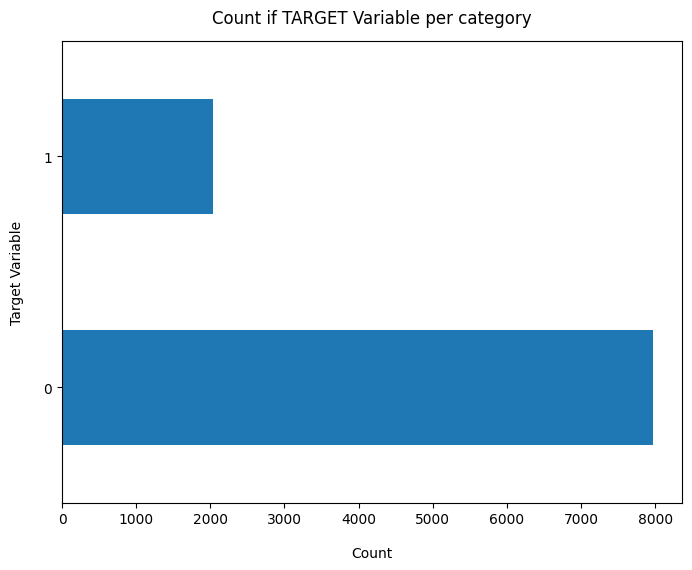

In [262]:
df['Exited'].value_counts().plot(kind='barh',figsize=(8,6))
plt.xlabel("Count",labelpad=14)
plt.ylabel("Target Variable",labelpad=14)
plt.title("Count if TARGET Variable per category",y=1.02);

In [263]:
print(df['Tenure'].max())

10


In [264]:
#imbalance dataset ===== upsampling/downsampling
#we are choosing upsampling here so that we dont loose anything

In [265]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [266]:
bins = [0, 2, 4, 6, 8, float('inf')]
labels = ['0–1', '2–3', '4–5', '6–7', '8+']

df['Tenure_group'] = pd.cut(df['Tenure'], bins=bins, labels=labels)
tenure=df['Tenure']
#df.drop(columns=['Tenure'],inplace=True)

In [267]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [268]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Geography', 'Gender', 'Tenure_group']
Numerical: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [269]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols),
    ]
)

In [270]:
df_dummies=pd.get_dummies(df)
df_dummies.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Tenure_group_0–1,Tenure_group_2–3,Tenure_group_4–5,Tenure_group_6–7,Tenure_group_8+
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,True,False,True,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,False,True,True,False,True,False,False,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,True,False,False,False,False,True,False
3,699,39,1,0.00,2,0,0,93826.63,0,True,False,False,True,False,True,False,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,False,True,True,False,True,False,False,False,False


<Axes: >

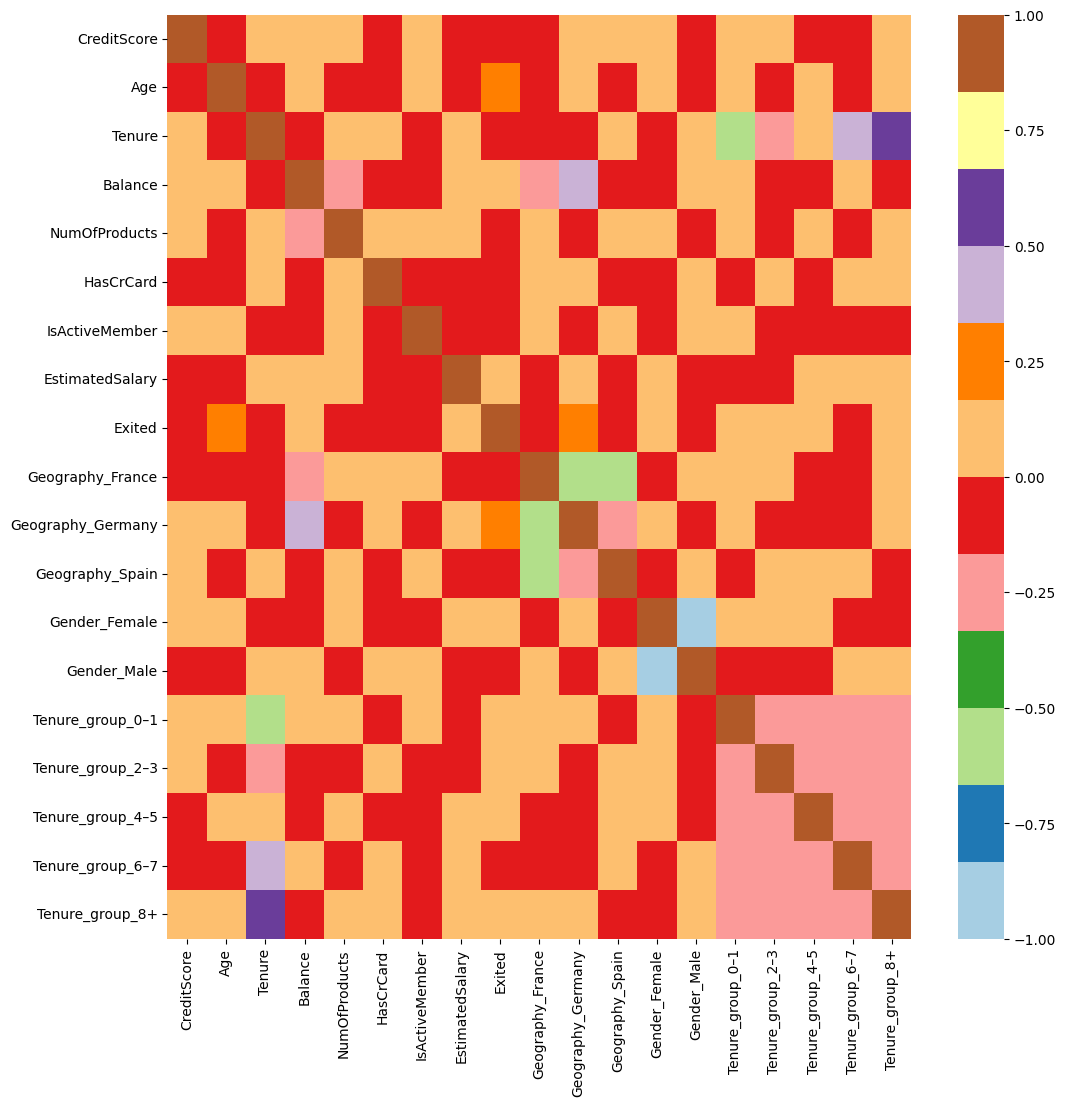

In [271]:
plt.figure(figsize=(12,12))
sns.heatmap(df_dummies.corr(),cmap="Paired")

Model Building

In [272]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
!pip install imbalanced-learn
from imblearn.combine import SMOTEENN

Defaulting to user installation because normal site-packages is not writeable


In [273]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.25)

In [274]:
model_=Pipeline(
    [
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(
            criterion="gini",
            random_state=100,
            max_depth=6,
            min_samples_leaf=8
        )),
    ]
)

In [275]:
model_.fit(x_train,y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [276]:
y_pred=model_.predict(x_test)

In [277]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2500,))

In [278]:
model_.score(x_test,y_pred)

1.0

In [279]:
print(classification_report(y_test,y_pred,labels=[0,1]))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1993
           1       0.77      0.44      0.56       507

    accuracy                           0.86      2500
   macro avg       0.82      0.70      0.74      2500
weighted avg       0.85      0.86      0.84      2500



In [280]:
print(confusion_matrix(y_test,y_pred))

[[1927   66]
 [ 286  221]]


In [281]:
sm=SMOTEENN()

In [282]:
X = pd.get_dummies(x, drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [283]:


sm = SMOTEENN(random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)

In [284]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    min_samples_leaf=8,
    random_state=100,
    class_weight=None  # SMOTE already balanced
)

model.fit(x_train_res, y_train_res)


,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,8
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,100
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [285]:
y_pred = model.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[1596  395]
 [ 160  349]]
              precision    recall  f1-score   support

           0       0.91      0.80      0.85      1991
           1       0.47      0.69      0.56       509

    accuracy                           0.78      2500
   macro avg       0.69      0.74      0.70      2500
weighted avg       0.82      0.78      0.79      2500



In [286]:
y_pred=model.predict(x_test)

In [287]:
y_pred

array([0, 0, 0, ..., 1, 0, 1], shape=(2500,))

In [288]:
print(confusion_matrix(y_test,y_pred))

[[1596  395]
 [ 160  349]]


In [289]:
print(classification_report(y_test,y_pred,labels=[0,1]))

              precision    recall  f1-score   support

           0       0.91      0.80      0.85      1991
           1       0.47      0.69      0.56       509

    accuracy                           0.78      2500
   macro avg       0.69      0.74      0.70      2500
weighted avg       0.82      0.78      0.79      2500



In [290]:
y.value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [291]:
from sklearn.ensemble import RandomForestClassifier

In [292]:
x1=df.drop(columns='Exited')

In [293]:
y1=df['Exited']

In [294]:
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,test_size=0.25,random_state=50)

In [295]:
model2=RandomForestClassifier()

In [296]:
x1_train = pd.get_dummies(x1_train, drop_first=True)
model2.fit(x1_train,y1_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [297]:
x1_test=pd.get_dummies(x1_test,drop_first=True)
y1_pred=model2.predict(x1_test)

In [298]:
confusion_matrix(y1_test,y1_pred)

array([[1918,   81],
       [ 274,  227]])

In [299]:
print(classification_report(y1_test,y1_pred,labels=[0,1]))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1999
           1       0.74      0.45      0.56       501

    accuracy                           0.86      2500
   macro avg       0.81      0.71      0.74      2500
weighted avg       0.85      0.86      0.84      2500





As both the models are not giving us the desired result lets move to gradient

In [341]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
LogisticRegression(class_weight="balanced")
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [342]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols),
    ]
)

pipe = Pipeline(
    [
        ("preprocess", preprocessor),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42
)

pipe.fit(X_train, y_train)


C:\Users\kalwa\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [343]:
print(df.head())
print(df.dtypes)
print(type(pipe))


   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  ...  Tenure_x_Products  \
0          1               1        101348.88  ...                  2   
1          0               1        112542.58  ...                  1   
2          1               0        113931.57  ...                 24   
3          0               0         93826.63  ...                  2   
4          1               1         79084.10  ...                  2   

  Balance_x_IsActive  CreditScore_x_Age  Balance_per_Product  \
0               0.00              25998       

In [344]:
y_prob_log = pipe.predict_proba(X_test)[:, 1]
print("Logistic ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Logistic ROC-AUC: 0.7914337505020136


In [347]:
gb_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)

gb_model.fit(X_train, y_train)

y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
y_pred_gb = (y_prob_gb >= 0.2).astype(int)  # threshold ≠ 0.5


In [348]:
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting ROC-AUC: 0.8791260080973418
[[1630  361]
 [ 114  395]]
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      1991
           1       0.52      0.78      0.62       509

    accuracy                           0.81      2500
   macro avg       0.73      0.80      0.75      2500
weighted avg       0.85      0.81      0.82      2500



In [349]:
df["Tenure_x_Products"] = tenure * df["NumOfProducts"]

In [350]:
df["Balance_x_IsActive"] = df["Balance"] * df["IsActiveMember"]

In [351]:
df["CreditScore_x_Age"] = df["CreditScore"] * df["Age"]

In [352]:
df["Balance_per_Product"] = df["Balance"] / (df["NumOfProducts"] + 1)

In [353]:
df["CreditScore_per_Age"] = df["CreditScore"] / df["Age"]

In [354]:
df["Products_per_Tenure"] = df["NumOfProducts"] / (tenure + 1)

In [355]:
df["HighBalance_Inactive"] = (
    (df["Balance"] > df["Balance"].median()) &
    (df["IsActiveMember"] == 0)
).astype(int)


In [356]:
df["LongTenure_LowProduct"] = (
    (tenure > 5) &
    (df["NumOfProducts"] == 1)
).astype(int)


In [357]:
df["Germany_HighBalance"] = (
    (df["Geography"] == "Germany") &
    (df["Balance"] > df["Balance"].median())
).astype(int)

In [358]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 30, 45, 60, 100],
    labels=["Young", "Mid", "Senior", "Elder"]
)


In [359]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

In [360]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical columns:", categorical_cols)


Categorical columns: ['Geography', 'Gender', 'Tenure_group', 'Age_Group']


In [361]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols),
    ]
)

In [362]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [363]:
gb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]
)


In [364]:
gb_pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [365]:
y_prob = gb_pipe.predict_proba(X_test)[:, 1]

print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, y_prob))

# Tune threshold for churn recall
threshold = 0.20
y_pred = (y_prob >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Gradient Boosting ROC-AUC: 0.8714739392705494
[[1312  281]
 [  95  312]]
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      1593
           1       0.53      0.77      0.62       407

    accuracy                           0.81      2000
   macro avg       0.73      0.80      0.75      2000
weighted avg       0.85      0.81      0.82      2000



In [366]:
for t in [0.5, 0.4, 0.3, 0.25, 0.2]:
    y_pred = (y_prob >= t).astype(int)
    print(f"\nThreshold {t}")
    print(classification_report(y_test, y_pred))



Threshold 0.5
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.87      0.87      0.86      2000


Threshold 0.4
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      1593
           1       0.70      0.55      0.62       407

    accuracy                           0.86      2000
   macro avg       0.80      0.75      0.77      2000
weighted avg       0.85      0.86      0.85      2000


Threshold 0.3
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1593
           1       0.63      0.64      0.63       407

    accuracy                           0.85      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.85      

In [367]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

recall_threshold_mask = recall[:-1] >= 0.80

if recall_threshold_mask.any():
    best_threshold = thresholds[recall_threshold_mask][-1]
else:
    best_threshold = 0.5  # fallback


In [368]:
for t in [0.5, 0.4, 0.3, 0.25, 0.2]:
    y_pred = (y_prob >= t).astype(int)
    print(f"\nThreshold {t}")
    print(classification_report(y_test, y_pred))



Threshold 0.5
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1593
           1       0.80      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.84      0.73      0.77      2000
weighted avg       0.87      0.87      0.86      2000


Threshold 0.4
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      1593
           1       0.70      0.55      0.62       407

    accuracy                           0.86      2000
   macro avg       0.80      0.75      0.77      2000
weighted avg       0.85      0.86      0.85      2000


Threshold 0.3
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      1593
           1       0.63      0.64      0.63       407

    accuracy                           0.85      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.85      

In [369]:
from imblearn.pipeline import Pipeline

smoteenn_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("resample", SMOTEENN(random_state=42)),
        ("model", GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )),
    ]
)


In [370]:
smoteenn_pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('resample', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [371]:
y_prob = smoteenn_pipe.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

threshold = 0.30
y_pred = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred))

ROC-AUC: 0.8506009861942064
              precision    recall  f1-score   support

           0       0.92      0.80      0.86      1593
           1       0.48      0.73      0.58       407

    accuracy                           0.79      2000
   macro avg       0.70      0.77      0.72      2000
weighted avg       0.83      0.79      0.80      2000



In [372]:
train_df = pd.concat([X_train, y_train], axis=1)

In [373]:
majority = train_df[train_df["Exited"] == 0]
minority = train_df[train_df["Exited"] == 1]

In [374]:
majority_downsampled = majority.sample(
    n=len(minority),
    random_state=42
)
train_downsampled = pd.concat([majority_downsampled, minority])

In [375]:
X_train_down = train_downsampled.drop("Exited", axis=1)
y_train_down = train_downsampled["Exited"]

In [376]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

preprocessor = ColumnTransformer(
    [
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols),
    ]
)

gb_pipe_down = Pipeline(
    [
        ("preprocess", preprocessor),
        ("model", GradientBoostingClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        )),
    ]
)

gb_pipe_down.fit(X_train_down, y_train_down)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [377]:
from sklearn.metrics import roc_auc_score, classification_report

y_prob = gb_pipe_down.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

y_pred = (y_prob >= 0.30).astype(int)
print(classification_report(y_test, y_pred))

ROC-AUC: 0.868142410515292
              precision    recall  f1-score   support

           0       0.96      0.57      0.71      1593
           1       0.35      0.90      0.50       407

    accuracy                           0.64      2000
   macro avg       0.65      0.74      0.61      2000
weighted avg       0.83      0.64      0.67      2000



save model

In [378]:
import pickle

In [382]:
with open("churn_gb_pipeline.pkl", "wb") as f:
    pickle.dump(gb_model, f)

with open("churn_threshold.pkl", "wb") as f:
    pickle.dump(0.2, f)


In [386]:
with open(r"C:\Users\kalwa\churn_gb_pipeline.pkl", "rb") as f:
    model = pickle.load(f)

In [387]:
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

with open(f"{MODEL_DIR}/churn_gb_pipeline.pkl", "wb") as f:
    pickle.dump(gb_model, f)

In [388]:
with open(f"{MODEL_DIR}/churn_gb_pipeline.pkl", "rb") as f:
    model = pickle.load(f)

In [389]:
model.score(X_test,y_test)

0.8675

In [390]:
input_data = pd.DataFrame([{
    "CreditScore": 600,
    "Geography": "Spain",
    "Gender": "Male",
    "Age": 40,
    "Tenure": 3,
    "Balance": 60000,
    "NumOfProducts": 2,
    "HasCrCard": 1,
    "IsActiveMember": 0,
    "EstimatedSalary": 50000,

    # engineered features (VERY IMPORTANT)
    "Tenure_x_Products": 3 * 2,
    "Products_per_Tenure": 2 / (3 + 1),
    "Balance_x_IsActive": 60000 * 0,
    "HighBalance_Inactive": 1
}])


In [394]:
def engineer_features(df):
    df = df.copy()

    # Interaction features
    df["Tenure_x_Products"] = df["Tenure"] * df["NumOfProducts"]
    df["Products_per_Tenure"] = df["NumOfProducts"] / (df["Tenure"] + 1)
    df["Balance_x_IsActive"] = df["Balance"] * df["IsActiveMember"]
    df["Balance_per_Product"] = df["Balance"] / (df["NumOfProducts"] + 1)

    df["CreditScore_x_Age"] = df["CreditScore"] * df["Age"]
    df["CreditScore_per_Age"] = df["CreditScore"] / df["Age"]

    # Binned features
    df["Tenure_group"] = pd.cut(
        df["Tenure"],
        bins=[0, 2, 4, 6, 8, float("inf")],
        labels=["0–1", "2–3", "4–5", "6–7", "8+"]
    )

    df["Age_Group"] = pd.cut(
        df["Age"],
        bins=[0, 30, 45, 60, 100],
        labels=["Young", "Mid", "Senior", "Elder"]
    )

    # Behavioral flags
    df["HighBalance_Inactive"] = (
        (df["Balance"] > df["Balance"].median()) &
        (df["IsActiveMember"] == 0)
    ).astype(int)

    df["LongTenure_LowProduct"] = (
        (df["Tenure"] > 5) &
        (df["NumOfProducts"] == 1)
    ).astype(int)

    df["Germany_HighBalance"] = (
        (df["Geography"] == "Germany") &
        (df["Balance"] > df["Balance"].median())
    ).astype(int)

    return df


In [395]:
raw_input = pd.DataFrame([{
    "CreditScore": 600,
    "Geography": "Spain",
    "Gender": "Male",
    "Age": 40,
    "Tenure": 3,
    "Balance": 60000,
    "NumOfProducts": 2,
    "HasCrCard": 1,
    "IsActiveMember": 0,
    "EstimatedSalary": 50000
}])

input_data = engineer_features(raw_input)

churn_probability = model.predict_proba(input_data)[:, 1][0]
churn_prediction = int(churn_probability >= threshold)

print(churn_probability, churn_prediction)


0.07634366913157332 0
